# EDA - E-commerce Sales and Customer Analytics

## Dataset
https://www.kaggle.com/datasets/datascikhan/e-commerce-sales-and-customer-analytics/data

In [1]:
# import libraries
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from pathlib import Path

/home/tom/projects/eda-practice/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ignore warnings in the notebook
import warnings
warnings.filterwarnings('ignore')

In [3]:
# download dataset
data_dir = "data" if Path("data").exists() else "./data"

# Download and extract dataset into the data folder
dataset_path = kagglehub.dataset_download(
    "datascikhan/e-commerce-sales-and-customer-analytics",
    output_dir=data_dir
)

print(f"Dataset downloaded to: {dataset_path}")

Dataset downloaded to: data


In [4]:
# setup visualisation's style and size
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

## Get general info about the dataset

In [5]:
# read `customer_master.csv` into dataframe
df = pd.read_csv('data/customer_master.csv')

In [6]:
df.head()

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53
3,CUST-000004,David Lopez,30,Male,VIP,Hawkinshaven,Pennsylvania,USA,East,53984,16.02
4,CUST-000005,Dakota Davis,55,Female,Consumer,New Carlymouth,Florida,USA,South,50994,41.34


In [7]:
df.shape

(25000, 11)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                25000 non-null  str    
 1   customer_name              25000 non-null  str    
 2   customer_age               25000 non-null  int64  
 3   gender                     25000 non-null  str    
 4   customer_segment           25000 non-null  str    
 5   customer_city              25000 non-null  str    
 6   customer_state             25000 non-null  str    
 7   customer_country           25000 non-null  str    
 8   region                     25000 non-null  str    
 9   customer_postal_code       25000 non-null  int64  
 10  customer_acquisition_cost  25000 non-null  float64
dtypes: float64(1), int64(2), str(8)
memory usage: 2.1 MB


## Visualisations

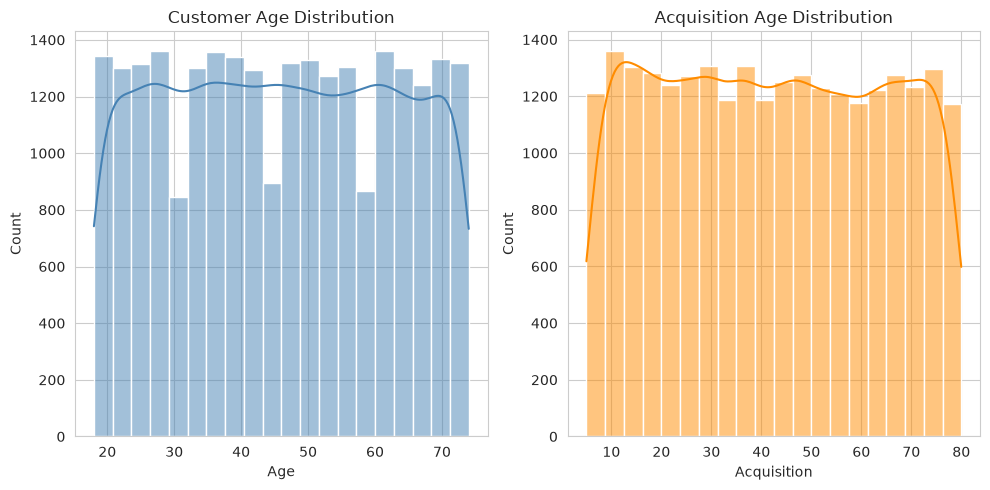

In [9]:
# Customer and Acquisition Age Distribution
fix, axes = plt.subplots(1, 2)

sns.histplot(df['customer_age'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')

sns.histplot(df['customer_acquisition_cost'], bins=20, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Acquisition Age Distribution')
axes[1].set_xlabel('Acquisition')

plt.tight_layout()
plt.show()

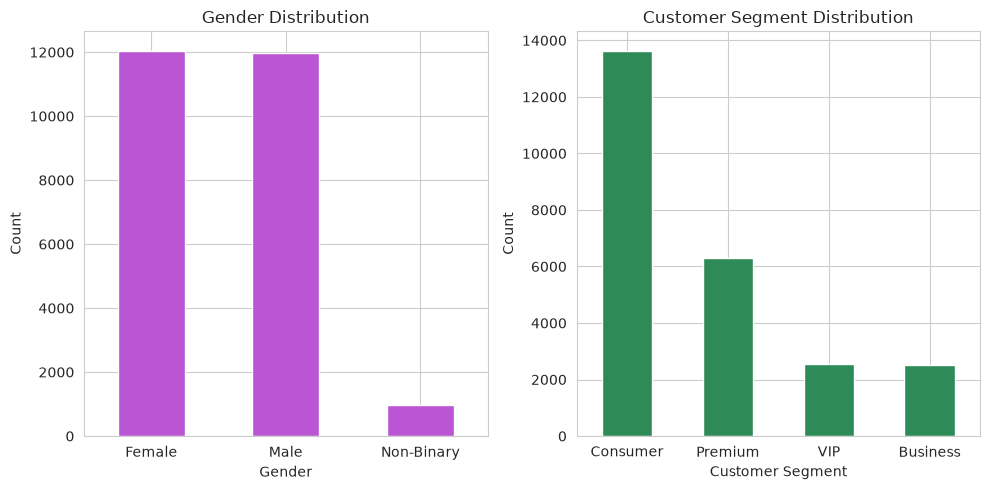

In [10]:
# Gender and Customer Segment Distribution

fix, axes = plt.subplots(1, 2)
df['gender'].value_counts().plot(kind='bar', ax=axes[0], color='mediumorchid')
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
# axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].tick_params(axis='x', rotation=0)

df['customer_segment'].value_counts().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Customer Segment Distribution')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Count')
# axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Check duplicate entries

In [11]:
unique_ids = df['customer_id'].is_unique
duplicate_rows = df.duplicated().sum()
duplicate_names = df['customer_name'].duplicated().sum()


In [12]:
pd.Series({
    'Unique Customer IDs': unique_ids,
    'Duplicate Rows': duplicate_rows,
    'Duplicate Customer Names': duplicate_names
})

Unique Customer IDs         True
Duplicate Rows                 0
Duplicate Customer Names    3369
dtype: object

## Summaries

In [13]:
# country_summary = df.groupby('customer_country').agg({
#     'customer_id': 'count',
#     'customer_age': 'mean',
#     'customer_acquisition_cost': 'mean'
# }).rename(columns={
#     'customer_id': 'Total Customers',
#     'customer_age': 'Average Age',
#     'customer_acquisition_cost': 'Average Acquisition Cost'
# }).sort_values(by='Total Customers', ascending=False)

# or
country_summary = df.groupby('customer_country').agg(
    Total_Customers=('customer_id', 'count'),
    Average_Age=('customer_age', 'mean'),
    Average_Acquisition_Cost=('customer_acquisition_cost', 'mean')
).sort_values(by='Total_Customers', ascending=False)

In [14]:
country_summary

,Total_Customers,Average_Age,Average_Acquisition_Cost
customer_country,,,
USA,14925,45.928777,42.085881
UK,3701,45.883545,42.274712
Germany,2046,45.640762,42.217571
Canada,1279,46.275215,42.612651
Australia,1233,45.689376,42.972758
India,1041,46.024976,41.831585
UAE,775,45.909677,41.280594


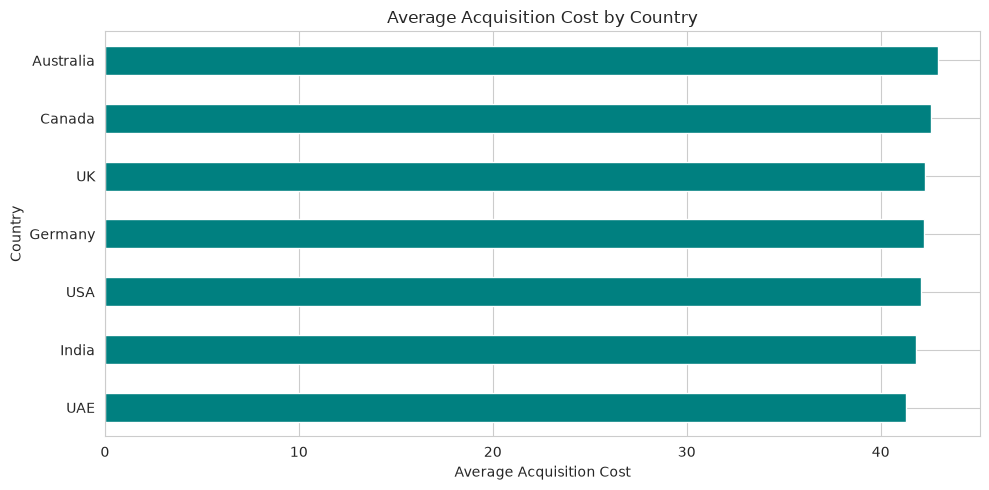

In [15]:
country_summary['Average_Acquisition_Cost'].sort_values().plot(kind='barh', color='teal')
plt.title('Average Acquisition Cost by Country')
plt.xlabel('Average Acquisition Cost')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

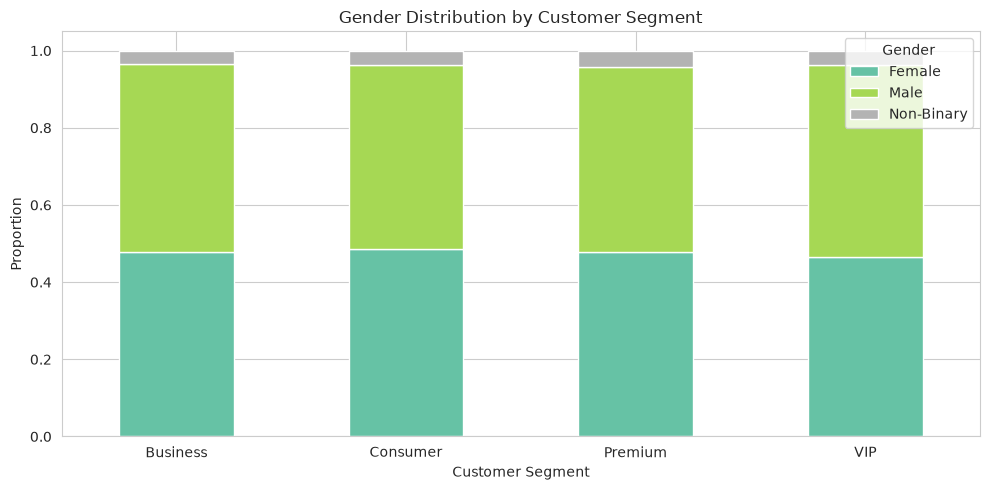

In [16]:
segment_gender = pd.crosstab(df['customer_segment'], df['gender'], normalize='index')
segment_gender.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Gender Distribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Gender', loc='upper right')
plt.tight_layout()
plt.show()

## Pivot Tables

In [17]:
pivot = df.pivot_table(
    values='customer_acquisition_cost',
    index='region',
    columns='customer_segment',
    aggfunc='mean'
    )

pivot

customer_segment,Business,Consumer,Premium,VIP
region,,,,
Central,42.665208,42.381241,42.033338,40.903996
East,41.582421,41.498164,42.068956,43.113654
North,43.024669,42.521355,42.938065,39.870359
South,42.419132,42.260161,41.927955,42.680490
West,42.257776,42.587711,41.129324,42.167195


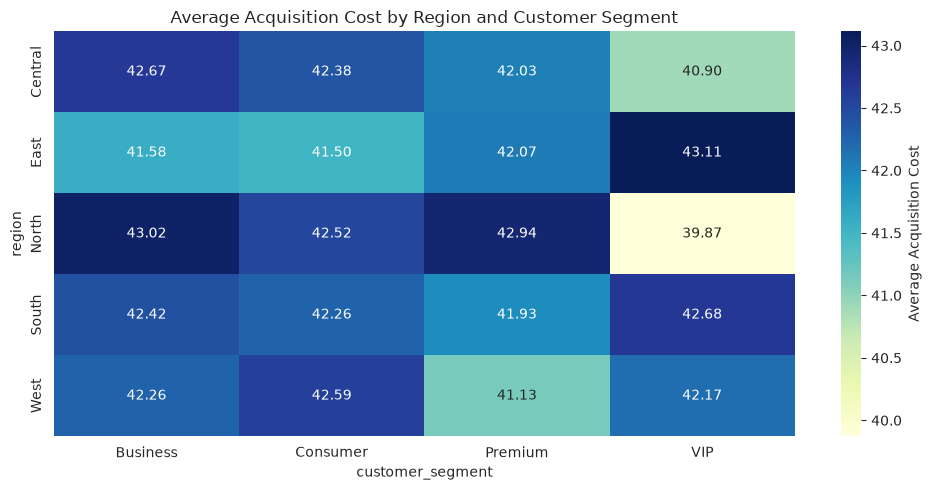

In [18]:
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap='YlGnBu',
    cbar_kws={
        'label': 'Average Acquisition Cost'
        })
plt.title('Average Acquisition Cost by Region and Customer Segment')
plt.tight_layout()
plt.show()

In [19]:
df['postal_len'] = df['customer_postal_code'].astype(str).str.len()
postal_by_country = pd.crosstab(df['customer_country'], df['postal_len'])
postal_by_country

postal_len,3,4,5
customer_country,,,
Australia,6,106,1121
Canada,7,124,1148
Germany,7,183,1856
India,2,91,948
UAE,3,56,716
UK,19,324,3358
USA,80,1368,13477


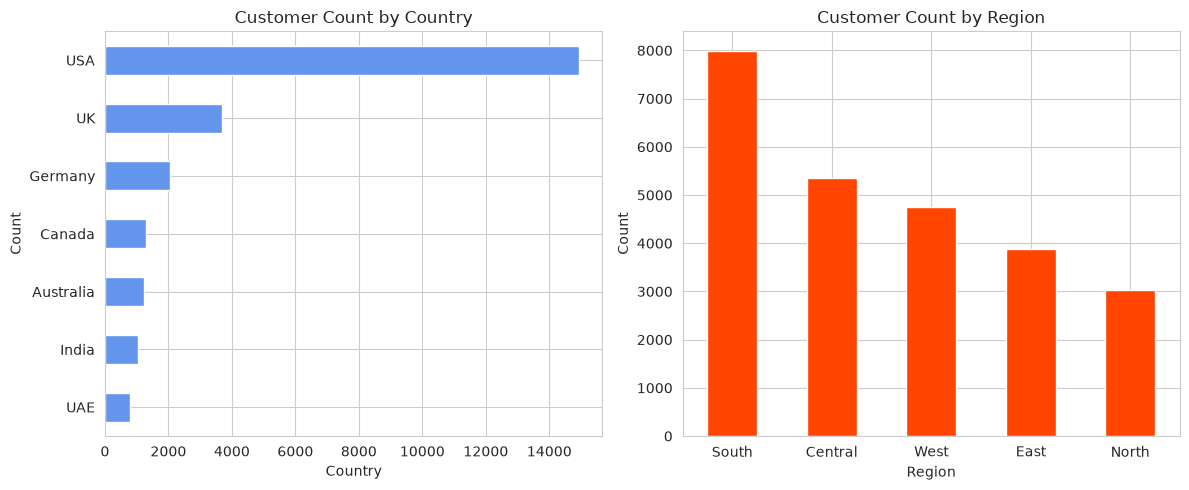

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['customer_country'].value_counts().plot(kind='barh', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Customer Count by Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Count')
axes[0].invert_yaxis()


df['region'].value_counts().plot(kind='bar', ax=axes[1], color='orangered')
axes[1].set_title('Customer Count by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

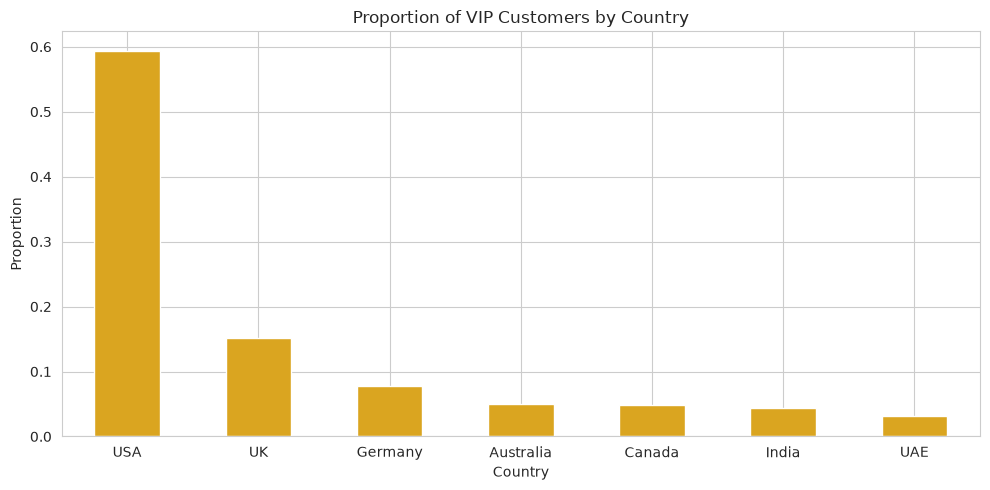

In [26]:
vip_by_country = df[df['customer_segment'] == 'VIP']['customer_country'].value_counts(normalize=True)
vip_by_country.plot(kind='bar', color='goldenrod')
plt.title('Proportion of VIP Customers by Country')
plt.xlabel('Country')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()